# Library

In [1]:
import sys, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, pickle, os

from src.preprocessing import full_preprocessing_pipeline
from src.features import prepare_all, add_engineered_features
from src.tuning import (
    tune_all_optuna,
    tune_all_randomized,
    tune_all_halving,
    summarize_tuning_comparison,
    n_trials, n_iter,
)
from src.evaluation import (
    show_comparison_table, plot_comparison,
    plot_before_after, plot_tuning_comparison,
    plot_confusion_matrices, plot_roc_curves,
    save_model,
)
from src.shap import run_shap_analysis
from sklearn.metrics import classification_report

os.makedirs('../models', exist_ok=True)

# Load Data

In [2]:
# konstanta tuning
n_trials  = 25    # Optuna: jumlah trial per model
n_iter    = 25    # RandomizedSearch: jumlah iterasi
n_folds   = 5     # CV folds
metric   = 'f1'
seed      = 42

In [3]:

# Load Data dan Prepare Data
df = full_preprocessing_pipeline('D:\Dibimbing.Id\Supply Chain\dataset\DataCoSupplyChainDataset.csv')
df = add_engineered_features(df)

data = prepare_all(df,
    scaler_s1_path='../models/scaler_s1.pkl',
    scaler_s2_path='../models/scaler_s2.pkl')

X_train_s1, X_test_s1 = data['s1']['X_train'], data['s1']['X_test']
y_train_s1, y_test_s1 = data['s1']['y_train'], data['s1']['y_test']
X_train_s2, X_test_s2 = data['s2']['X_train'], data['s2']['X_test']
y_train_s2, y_test_s2 = data['s2']['y_train'], data['s2']['y_test']


Dataset berjumlah 180519 baris dan 53 kolom
Kolom yang telah dihapus (22): ['Delivery Status', 'shipping date (DateOrders)', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Street', 'Customer Id', 'Order Customer Id', 'Order Id', 'Order Item Id', 'Order Item Cardprod Id', 'Product Card Id', 'Product Category Id', 'Category Id', 'Department Id', 'Product Image', 'Customer Zipcode', 'Latitude', 'Longitude', 'Product Description', 'Order Zipcode']
Tidak ada missing values.

Kolom yang memiliki missing value lebih dari 50%: []
Jumlah kolom sebelum didrop: 31
Jumlah kolom setelah didrop: 31
Tidak ada data yang duplicates.
Fitur redundan yang didrop: ['Order Profit Per Order', 'Order Item Product Price', 'Order Item Total']
Kolom kategorik yang didrop (10): ['Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'Market', 'Order City', 'Order State', 'order date (DateOrders)', 'Order Status', 'Order Country']
Kolom konstan di-drop: ['

In [4]:
# Load Baseline Result
with open('../models/_results_baseline.pkl', 'rb') as f:
    baseline_data = pickle.load(f)

results_baseline_s1 = baseline_data['s1']
results_baseline_s2 = baseline_data['s2']
df_res_baseline_s1  = baseline_data['df_s1']
df_res_baseline_s2  = baseline_data['df_s2']

In [5]:
# Load Model Terbaik dari Baseline
best_s1_name = df_res_baseline_s1.iloc[0]['Model']
best_s2_name = df_res_baseline_s2.iloc[0]['Model']
print(f"Model terbaik Skenario 1 (baseline): {best_s1_name}")
print(f"Model terbaik Skenario 2 (baseline): {best_s2_name}")
print(f"\nKonfigurasi: Optuna n_trials={n_trials}, RandomizedSearch n_iter={n_iter}")

Model terbaik Skenario 1 (baseline): Logistic Regression
Model terbaik Skenario 2 (baseline): Extra Trees

Konfigurasi: Optuna n_trials=25, RandomizedSearch n_iter=25


# Optuna

## Skenario 1 - Pre Shipment

In [6]:
results_optuna_s1 = tune_all_optuna(
    X_train_s1, X_test_s1, y_train_s1, y_test_s1,
    label='Skenario 1 - Pre-Shipment',
    n_trials=n_trials,
)



[Optuna] Tuning Logistic Regression — Skenario 1 - Pre-Shipment
  Method   : Optuna
  Time     : 1540.17s
  CV F1    : 0.6745
  Test F1  : 0.6764
  ROC-AUC  : 0.6891
  Params   : {'C': 1.3311216080736887, 'solver': 'saga'}

[Optuna] Tuning Decision Tree — Skenario 1 - Pre-Shipment
  Method   : Optuna
  Time     : 21.84s
  CV F1    : 0.6642
  Test F1  : 0.6647
  ROC-AUC  : 0.7361
  Params   : {'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 5, 'criterion': 'gini'}

[Optuna] Tuning Random Forest — Skenario 1 - Pre-Shipment
  Method   : Optuna
  Time     : 145.29s
  CV F1    : 0.6744
  Test F1  : 0.6767
  ROC-AUC  : 0.7419
  Params   : {'n_estimators': 120, 'max_depth': 3, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'sqrt'}

[Optuna] Tuning Extra Trees — Skenario 1 - Pre-Shipment
  Method   : Optuna
  Time     : 107.65s
  CV F1    : 0.6744
  Test F1  : 0.6767
  ROC-AUC  : 0.7416
  Params   : {'n_estimators': 115, 'max_depth': 3, 'min_samples_split': 20, 


--- Tabel Perbandingan [Optuna — Skenario 1] ---
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
1        Random Forest    0.6919     0.7968  0.5880    0.6767   0.7419            1.95
2          Extra Trees    0.6919     0.7968  0.5880    0.6767   0.7416            1.29
3  Logistic Regression    0.6518     0.6895  0.6638    0.6764   0.6891            6.27
4             LightGBM    0.6954     0.8128  0.5775    0.6753   0.7424            0.44
5              XGBoost    0.6954     0.8130  0.5772    0.6751   0.7425            0.43
6             CatBoost    0.6928     0.8190  0.5645    0.6683   0.7370            4.41
7        Decision Tree    0.6917     0.8235  0.5572    0.6647   0.7361            0.36

Model terbaik: Random Forest (F1=0.6767)


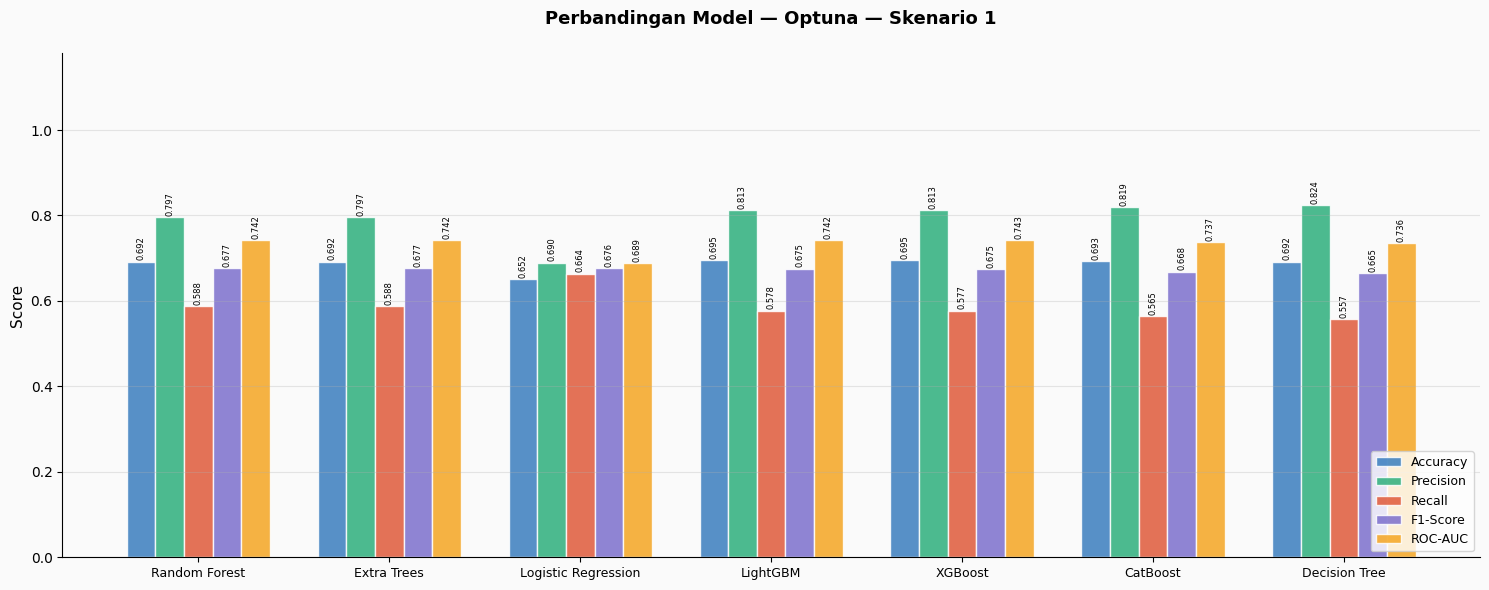

In [7]:
df_optuna_s1 = show_comparison_table(results_optuna_s1, 'Optuna — Skenario 1')
plot_comparison(df_optuna_s1, 'Optuna — Skenario 1')

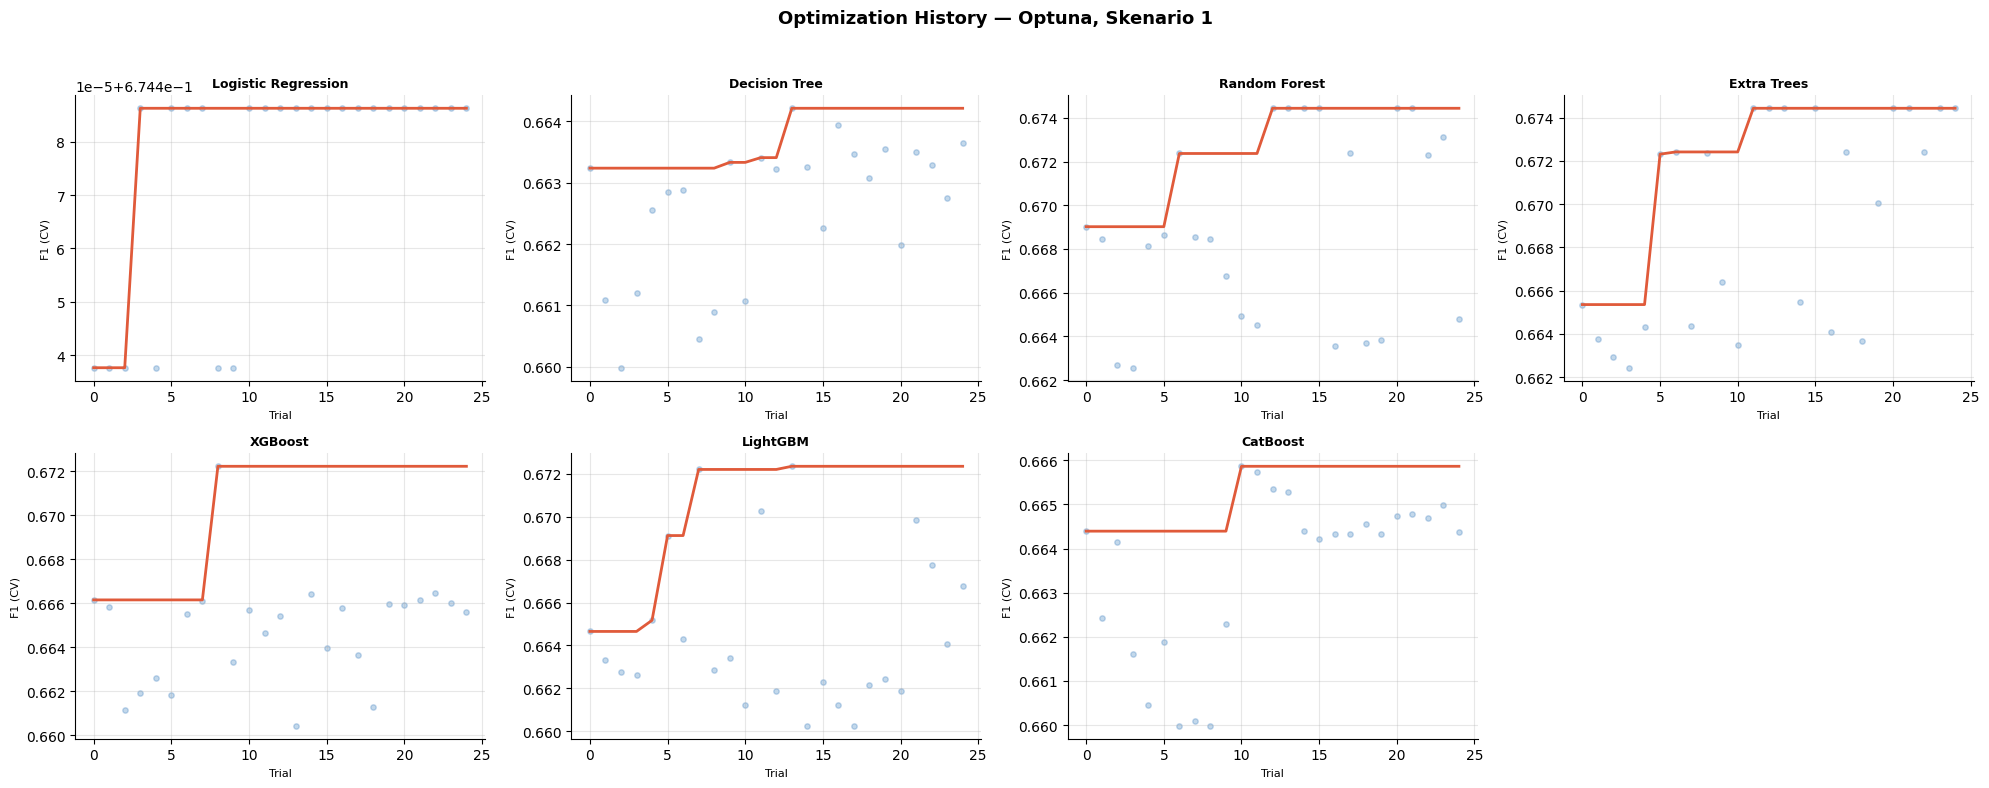

In [8]:
# Optimization History — semua model
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, res in enumerate(results_optuna_s1):
    if '_study' not in res: continue
    study  = res['_study']
    vals   = [t.value for t in study.trials]
    best_so_far = [max(vals[:j+1]) for j in range(len(vals))]
    ax = axes[i]
    ax.scatter(range(len(vals)), vals, alpha=0.3, color='#3A7EBF', s=15)
    ax.plot(range(len(best_so_far)), best_so_far, color='#E05A3A', linewidth=2)
    ax.set_title(res['Model'], fontsize=9, fontweight='bold')
    ax.set_xlabel('Trial', fontsize=8); ax.set_ylabel('F1 (CV)', fontsize=8)
    ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
for j in range(len(results_optuna_s1), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Optimization History — Optuna, Skenario 1\n', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

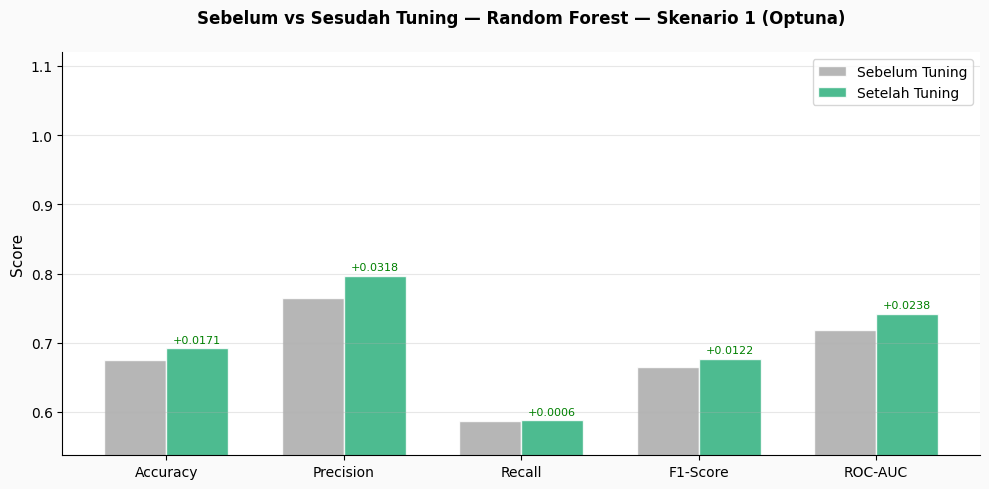

                 precision    recall  f1-score   support

Tidak Terlambat       0.62      0.82      0.71     16308
      Terlambat       0.80      0.59      0.68     19796

       accuracy                           0.69     36104
      macro avg       0.71      0.70      0.69     36104
   weighted avg       0.72      0.69      0.69     36104



In [9]:
# Sebelum vs Sesudah — model terbaik S1
best_optuna_s1 = df_optuna_s1.iloc[0]['Model']
before_s1 = next(r for r in results_baseline_s1 if r['Model'] == best_optuna_s1)
after_s1  = next(r for r in results_optuna_s1  if r['Model'] == best_optuna_s1)
plot_before_after(before_s1, after_s1, f'{best_optuna_s1} — Skenario 1 (Optuna)')
print(classification_report(y_test_s1, after_s1['_y_pred'],
      target_names=['Tidak Terlambat','Terlambat']))


## Skenario 2 - Full Order Profile

In [10]:
results_optuna_s2 = tune_all_optuna(
    X_train_s2, X_test_s2, y_train_s2, y_test_s2,
    label='Skenario 2 - Full Order Profile',
    n_trials=n_trials,
)


[Optuna] Tuning Logistic Regression — Skenario 2 - Full Order Profile
  Method   : Optuna
  Time     : 4214.26s
  CV F1    : 0.6746
  Test F1  : 0.6767
  ROC-AUC  : 0.6899
  Params   : {'C': 1.3311216080736887, 'solver': 'saga'}

[Optuna] Tuning Decision Tree — Skenario 2 - Full Order Profile
  Method   : Optuna
  Time     : 73.4s
  CV F1    : 0.6678
  Test F1  : 0.6696
  ROC-AUC  : 0.744
  Params   : {'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 2, 'criterion': 'entropy'}

[Optuna] Tuning Random Forest — Skenario 2 - Full Order Profile
  Method   : Optuna
  Time     : 375.1s
  CV F1    : 0.6754
  Test F1  : 0.6798
  ROC-AUC  : 0.7584
  Params   : {'n_estimators': 200, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2'}

[Optuna] Tuning Extra Trees — Skenario 2 - Full Order Profile
  Method   : Optuna
  Time     : 310.31s
  CV F1    : 0.7118
  Test F1  : 0.7124
  ROC-AUC  : 0.7337
  Params   : {'n_estimators': 297, 'max_depth': 3, '


--- Tabel Perbandingan [Optuna — Skenario 2] ---
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
1          Extra Trees    0.6011     0.5891  0.9010    0.7124   0.7337            3.27
2              XGBoost    0.6908     0.7656  0.6285    0.6903   0.7497            4.19
3             LightGBM    0.6891     0.7683  0.6198    0.6861   0.7463            2.14
4             CatBoost    0.6925     0.7866  0.6026    0.6824   0.7454           18.37
5        Random Forest    0.7001     0.8199  0.5805    0.6798   0.7584            5.49
6  Logistic Regression    0.6531     0.6920  0.6621    0.6767   0.6899           24.38
7        Decision Tree    0.6966     0.8311  0.5606    0.6696   0.7440            2.32

Model terbaik: Extra Trees (F1=0.7124)


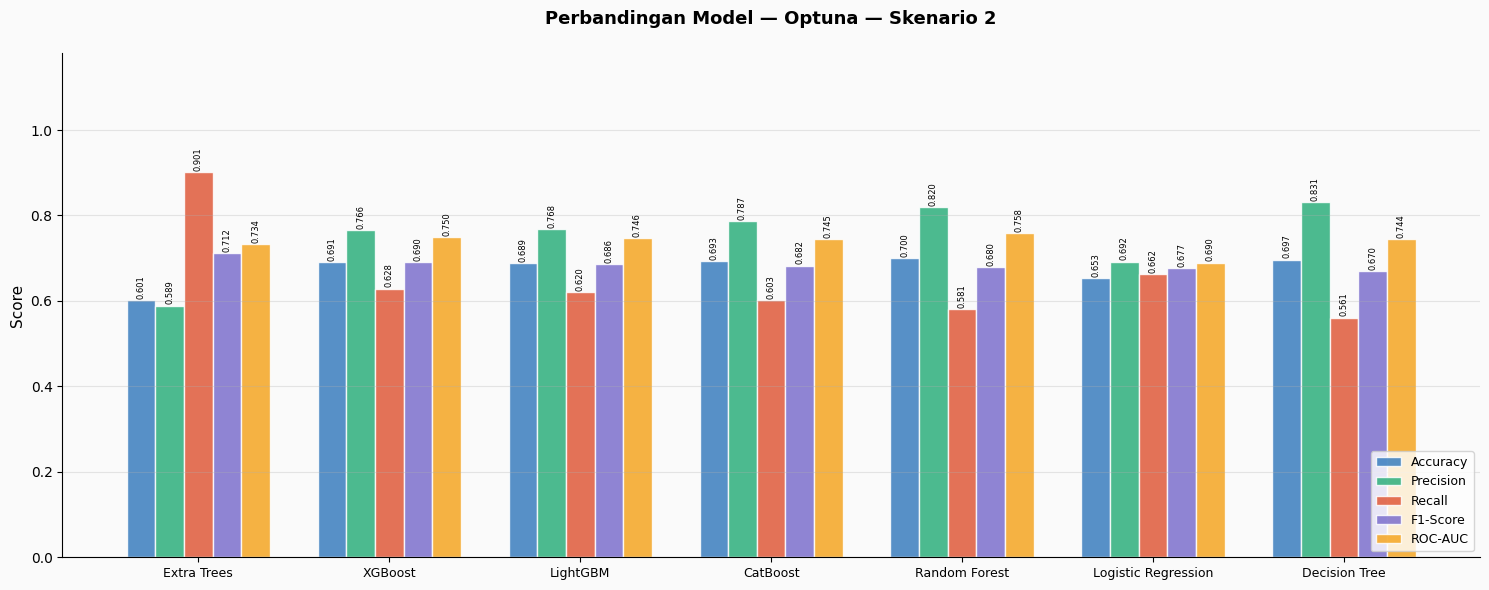

In [11]:
df_optuna_s2 = show_comparison_table(results_optuna_s2, 'Optuna — Skenario 2')
plot_comparison(df_optuna_s2, 'Optuna — Skenario 2')


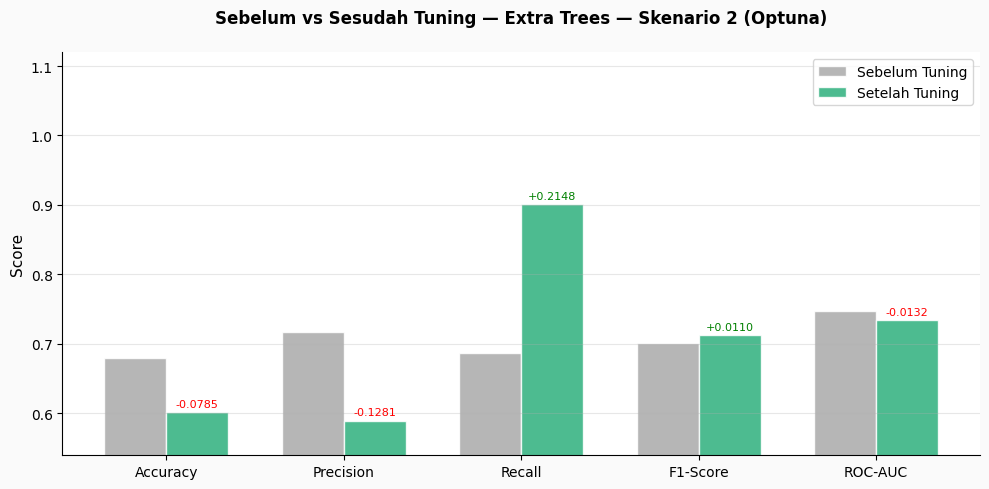

                 precision    recall  f1-score   support

Tidak Terlambat       0.66      0.24      0.35     16308
      Terlambat       0.59      0.90      0.71     19796

       accuracy                           0.60     36104
      macro avg       0.63      0.57      0.53     36104
   weighted avg       0.62      0.60      0.55     36104



In [12]:
best_optuna_s2 = df_optuna_s2.iloc[0]['Model']
before_s2 = next(r for r in results_baseline_s2 if r['Model'] == best_optuna_s2)
after_s2  = next(r for r in results_optuna_s2  if r['Model'] == best_optuna_s2)
plot_before_after(before_s2, after_s2, f'{best_optuna_s2} — Skenario 2 (Optuna)')
print(classification_report(y_test_s2, after_s2['_y_pred'],
      target_names=['Tidak Terlambat','Terlambat']))


# RandomizedSearchCV 

## Skenario 1 - Pre Shipment


[RandomizedSearchCV] Tuning Logistic Regression — Skenario 1 - Pre-Shipment
  Method   : RandomizedSearchCV
  Time     : 491.0s
  CV F1    : 0.6745
  Test F1  : 0.6769
  ROC-AUC  : 0.7117
  Params   : {'solver': 'saga', 'C': np.float64(3.2374575428176433)}

[RandomizedSearchCV] Tuning Decision Tree — Skenario 1 - Pre-Shipment
  Method   : RandomizedSearchCV
  Time     : 4.91s
  CV F1    : 0.666
  Test F1  : 0.6679
  ROC-AUC  : 0.729
  Params   : {'min_samples_split': 16, 'min_samples_leaf': 10, 'max_depth': 17, 'criterion': 'entropy'}

[RandomizedSearchCV] Tuning Random Forest — Skenario 1 - Pre-Shipment
  Method   : RandomizedSearchCV
  Time     : 150.87s
  CV F1    : 0.6744
  Test F1  : 0.6767
  ROC-AUC  : 0.7416
  Params   : {'n_estimators': 150, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 3}

[RandomizedSearchCV] Tuning Extra Trees — Skenario 1 - Pre-Shipment
  Method   : RandomizedSearchCV
  Time     : 111.7s
  CV F1    : 0.6744
  Test F1 

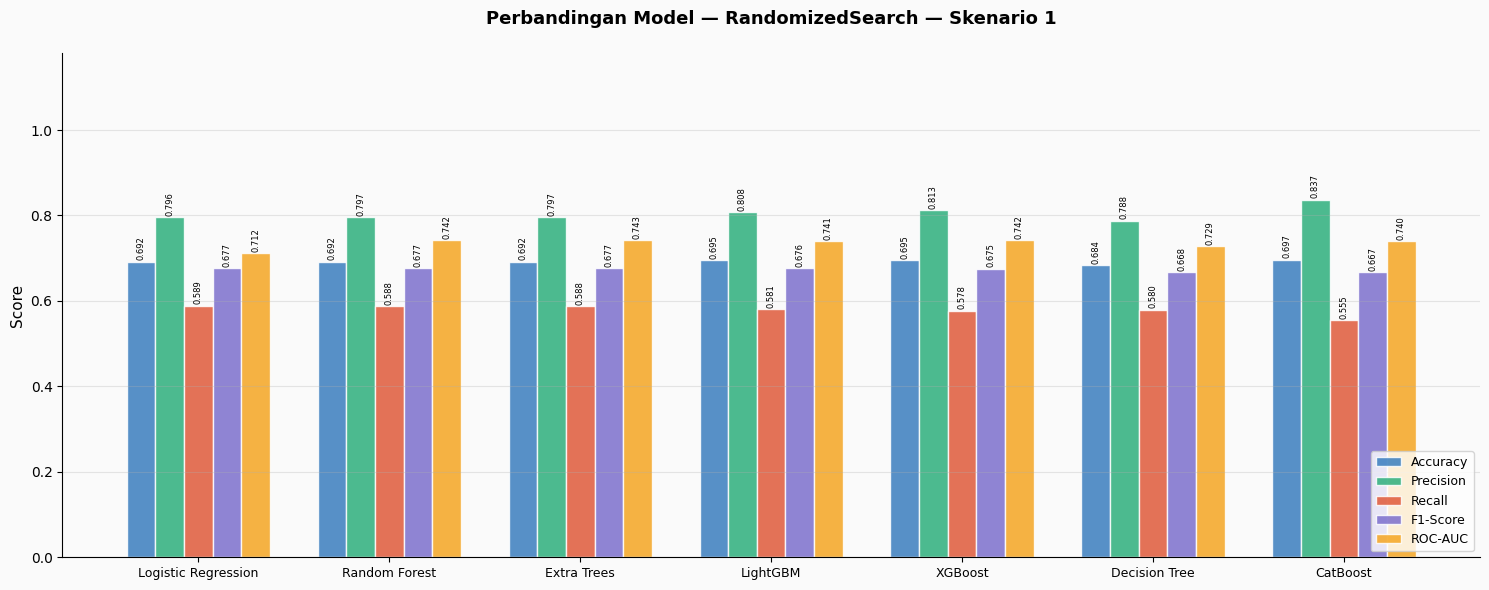

In [13]:
results_random_s1 = tune_all_randomized(
    X_train_s1, X_test_s1, y_train_s1, y_test_s1,
    label='Skenario 1 - Pre-Shipment', n_iter=n_iter,
)
df_random_s1 = show_comparison_table(results_random_s1, 'RandomizedSearch — Skenario 1')
plot_comparison(df_random_s1, 'RandomizedSearch — Skenario 1')


## Skenario 2 - Full Order Profilw


[RandomizedSearchCV] Tuning Logistic Regression — Skenario 2 - Full Order Profile
  Method   : RandomizedSearchCV
  Time     : 1698.52s
  CV F1    : 0.6746
  Test F1  : 0.6769
  ROC-AUC  : 0.7112
  Params   : {'solver': 'saga', 'C': np.float64(3.2374575428176433)}

[RandomizedSearchCV] Tuning Decision Tree — Skenario 2 - Full Order Profile
  Method   : RandomizedSearchCV
  Time     : 37.12s
  CV F1    : 0.6678
  Test F1  : 0.6696
  ROC-AUC  : 0.744
  Params   : {'min_samples_split': 17, 'min_samples_leaf': 2, 'max_depth': 15, 'criterion': 'entropy'}

[RandomizedSearchCV] Tuning Random Forest — Skenario 2 - Full Order Profile
  Method   : RandomizedSearchCV
  Time     : 215.55s
  CV F1    : 0.6779
  Test F1  : 0.6963
  ROC-AUC  : 0.7352
  Params   : {'n_estimators': 300, 'min_samples_split': 16, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 3}

[RandomizedSearchCV] Tuning Extra Trees — Skenario 2 - Full Order Profile
  Method   : RandomizedSearchCV
  Time     : 260.74s
  

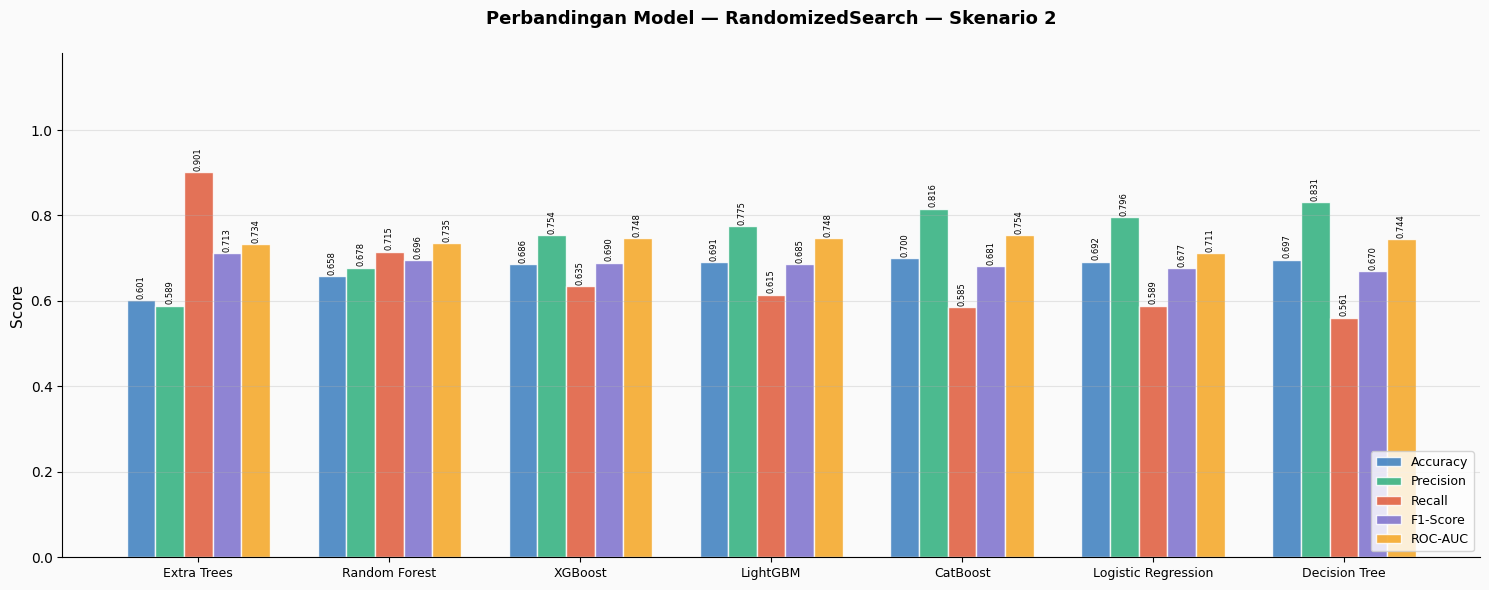

In [15]:
results_random_s2 = tune_all_randomized(
    X_train_s2, X_test_s2, y_train_s2, y_test_s2,
    label='Skenario 2 - Full Order Profile', n_iter=n_iter,
)
df_random_s2 = show_comparison_table(results_random_s2, 'RandomizedSearch — Skenario 2')
plot_comparison(df_random_s2, 'RandomizedSearch — Skenario 2')


# HalvingRandomSearchCV

## Skenario 1 - Pre Shipment

In [23]:
import importlib
import src.tuning
importlib.reload(src.tuning)
from src.tuning import tune_all_halving


[HalvingRandomSearchCV] Tuning Logistic Regression — Skenario 1 - Pre-Shipment
  Method   : HalvingRandomSearchCV
  Time     : 14.71s
  CV F1    : 0.648
  Test F1  : 0.6767
  ROC-AUC  : 0.724
  Params   : {'solver': 'lbfgs', 'C': np.float64(5.689866029018293)}

[HalvingRandomSearchCV] Tuning Decision Tree — Skenario 1 - Pre-Shipment
  Method   : HalvingRandomSearchCV
  Time     : 3.98s
  CV F1    : 0.6546
  Test F1  : 0.6676
  ROC-AUC  : 0.7315
  Params   : {'min_samples_split': 15, 'min_samples_leaf': 4, 'max_depth': 13, 'criterion': 'entropy'}

[HalvingRandomSearchCV] Tuning Random Forest — Skenario 1 - Pre-Shipment
  Method   : HalvingRandomSearchCV
  Time     : 17.43s
  CV F1    : 0.6775
  Test F1  : 0.6756
  ROC-AUC  : 0.7414
  Params   : {'n_estimators': 300, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 4}

[HalvingRandomSearchCV] Tuning Extra Trees — Skenario 1 - Pre-Shipment
  Method   : HalvingRandomSearchCV
  Time     : 14.16s
  CV F1  

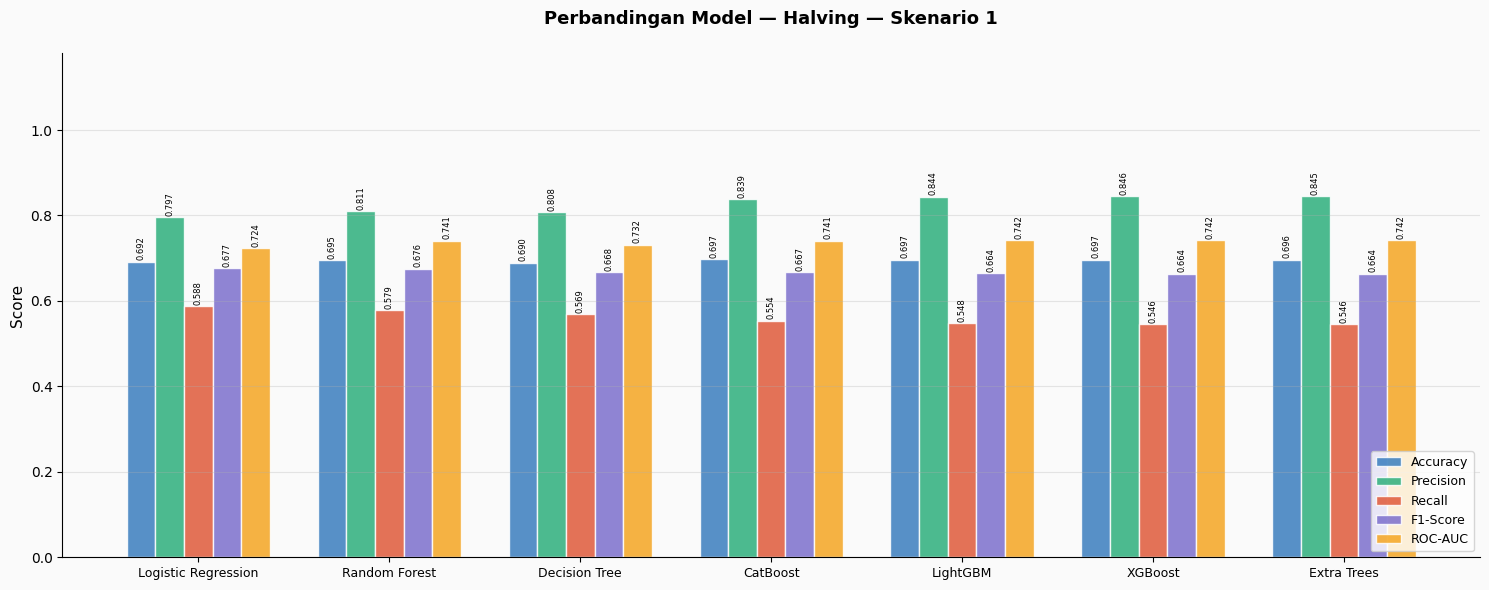

In [24]:
results_halving_s1 = tune_all_halving(
    X_train_s1, X_test_s1, y_train_s1, y_test_s1,
    label='Skenario 1 - Pre-Shipment',
)
df_halving_s1 = show_comparison_table(results_halving_s1, 'Halving — Skenario 1')
plot_comparison(df_halving_s1, 'Halving — Skenario 1')


## Skenario 2 - Full Order Profile


[HalvingRandomSearchCV] Tuning Logistic Regression — Skenario 2 - Full Order Profile
  Method   : HalvingRandomSearchCV
  Time     : 41.12s
  CV F1    : 0.6154
  Test F1  : 0.6767
  ROC-AUC  : 0.7243
  Params   : {'solver': 'lbfgs', 'C': np.float64(0.04714866363457394)}

[HalvingRandomSearchCV] Tuning Decision Tree — Skenario 2 - Full Order Profile
  Method   : HalvingRandomSearchCV
  Time     : 4.71s
  CV F1    : 0.6707
  Test F1  : 0.6627
  ROC-AUC  : 0.7429
  Params   : {'min_samples_split': 12, 'min_samples_leaf': 5, 'max_depth': 5, 'criterion': 'gini'}

[HalvingRandomSearchCV] Tuning Random Forest — Skenario 2 - Full Order Profile
  Method   : HalvingRandomSearchCV
  Time     : 16.25s
  CV F1    : 0.6729
  Test F1  : 0.6769
  ROC-AUC  : 0.7533
  Params   : {'n_estimators': 150, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 14}

[HalvingRandomSearchCV] Tuning Extra Trees — Skenario 2 - Full Order Profile
  Method   : HalvingRandomSearchCV
  Ti

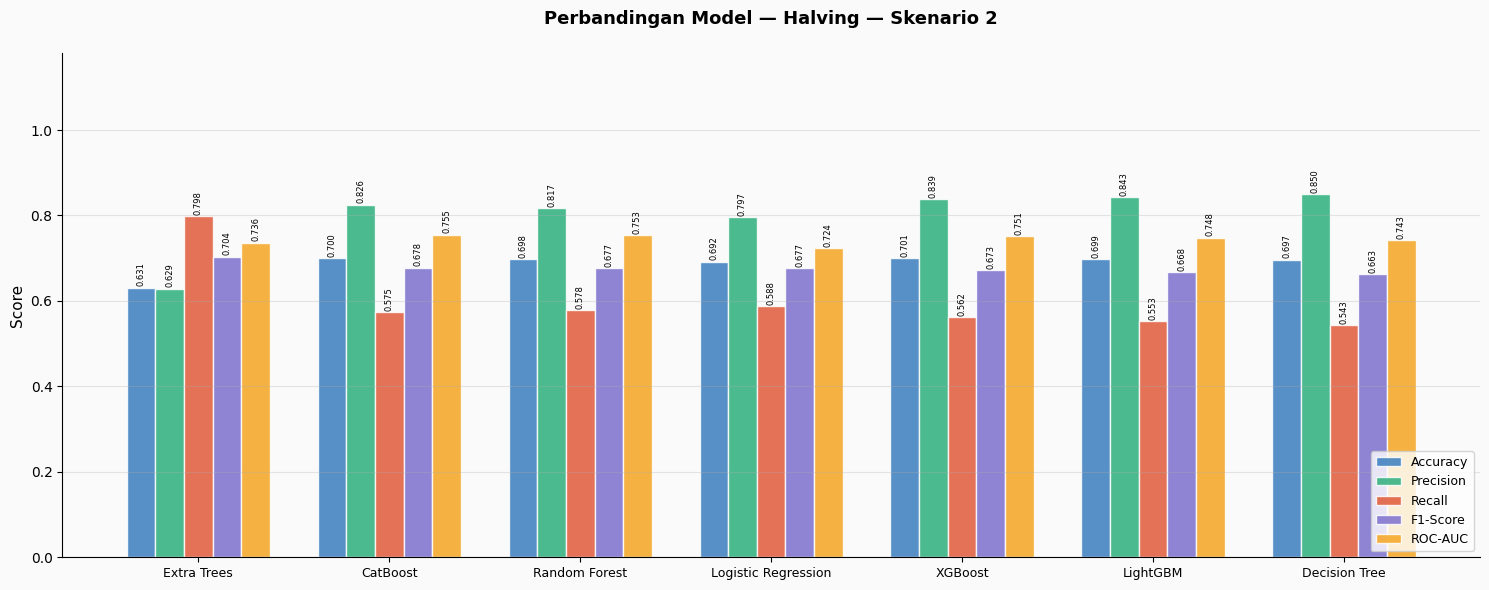

In [25]:
results_halving_s2 = tune_all_halving(
    X_train_s2, X_test_s2, y_train_s2, y_test_s2,
    label='Skenario 2 - Full Order Profile',
)
df_halving_s2 = show_comparison_table(results_halving_s2, 'Halving — Skenario 2')
plot_comparison(df_halving_s2, 'Halving — Skenario 2')


# Perbandingan 3 Tuning


=== Perbandingan 3 Metode Tuning [Skenario 1 - Pre-Shipment] ===
Method               Baseline  HalvingRandomSearchCV  Optuna  RandomizedSearchCV
Model                                                                           
CatBoost               0.6682                 0.6671  0.6683              0.6672
Decision Tree          0.6551                 0.6676  0.6647              0.6679
Extra Trees            0.6576                 0.6637  0.6767              0.6767
LightGBM               0.6655                 0.6644  0.6753              0.6761
Logistic Regression    0.6767                 0.6767  0.6764              0.6769
MLP                    0.6758                    NaN     NaN                 NaN
Random Forest          0.6645                 0.6756  0.6767              0.6767
XGBoost                0.6679                 0.6638  0.6751              0.6753


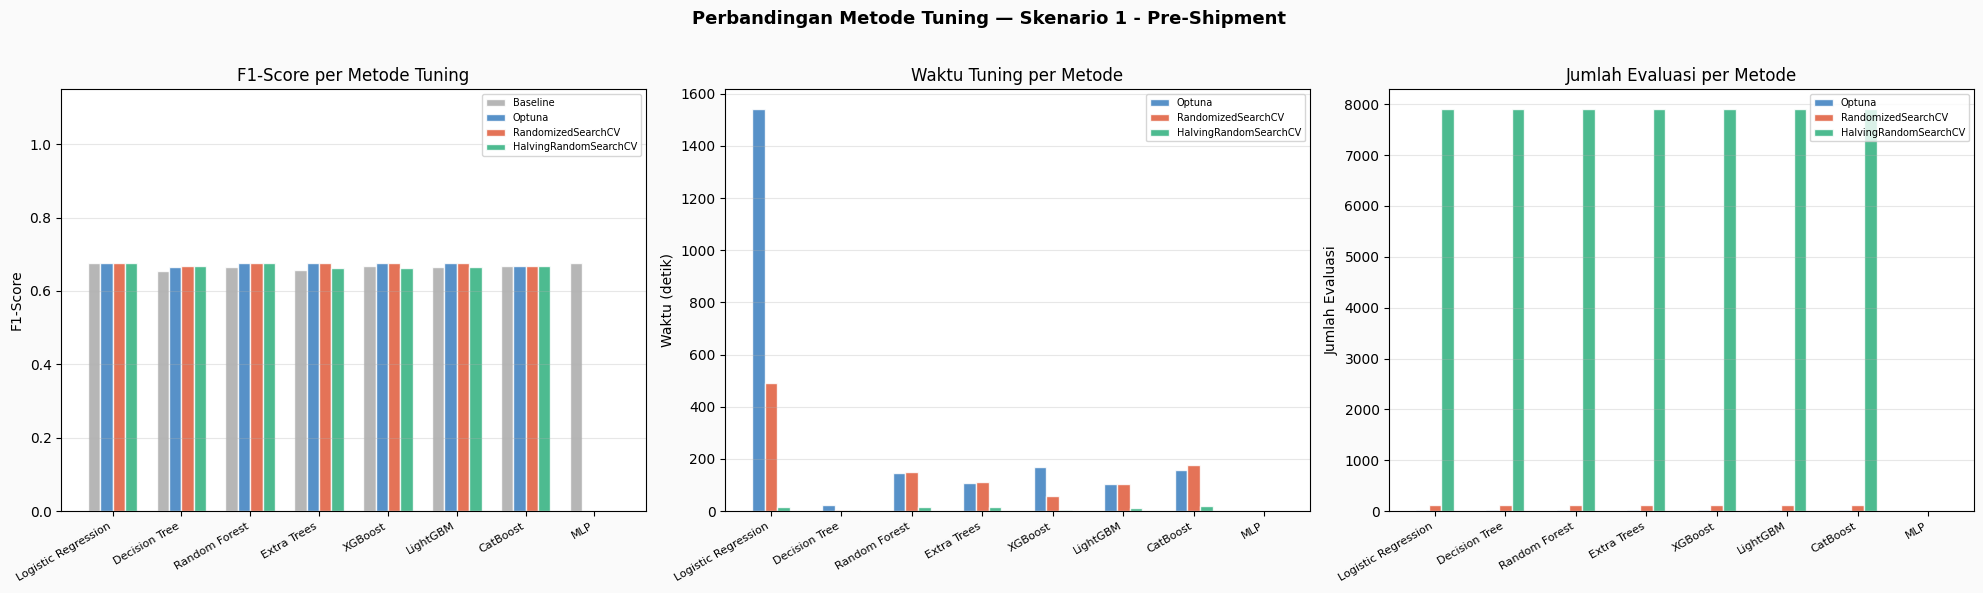

In [26]:
# Skenario 1
df_cmp_s1 = summarize_tuning_comparison(
    results_baseline_s1, results_optuna_s1,
    results_random_s1,   results_halving_s1,
    label='Skenario 1 - Pre-Shipment',
)
plot_tuning_comparison(df_cmp_s1, 'Skenario 1 - Pre-Shipment')


=== Perbandingan 3 Metode Tuning [Skenario 2 - Full Order Profile] ===
Method               Baseline  HalvingRandomSearchCV  Optuna  RandomizedSearchCV
Model                                                                           
CatBoost               0.6812                 0.6776  0.6824              0.6815
Decision Tree          0.6597                 0.6627  0.6696              0.6696
Extra Trees            0.7014                 0.7035  0.7124              0.7125
LightGBM               0.6716                 0.6679  0.6861              0.6854
Logistic Regression    0.6766                 0.6767  0.6767              0.6769
MLP                    0.6807                    NaN     NaN                 NaN
Random Forest          0.6958                 0.6769  0.6798              0.6963
XGBoost                0.6786                 0.6729  0.6903              0.6896


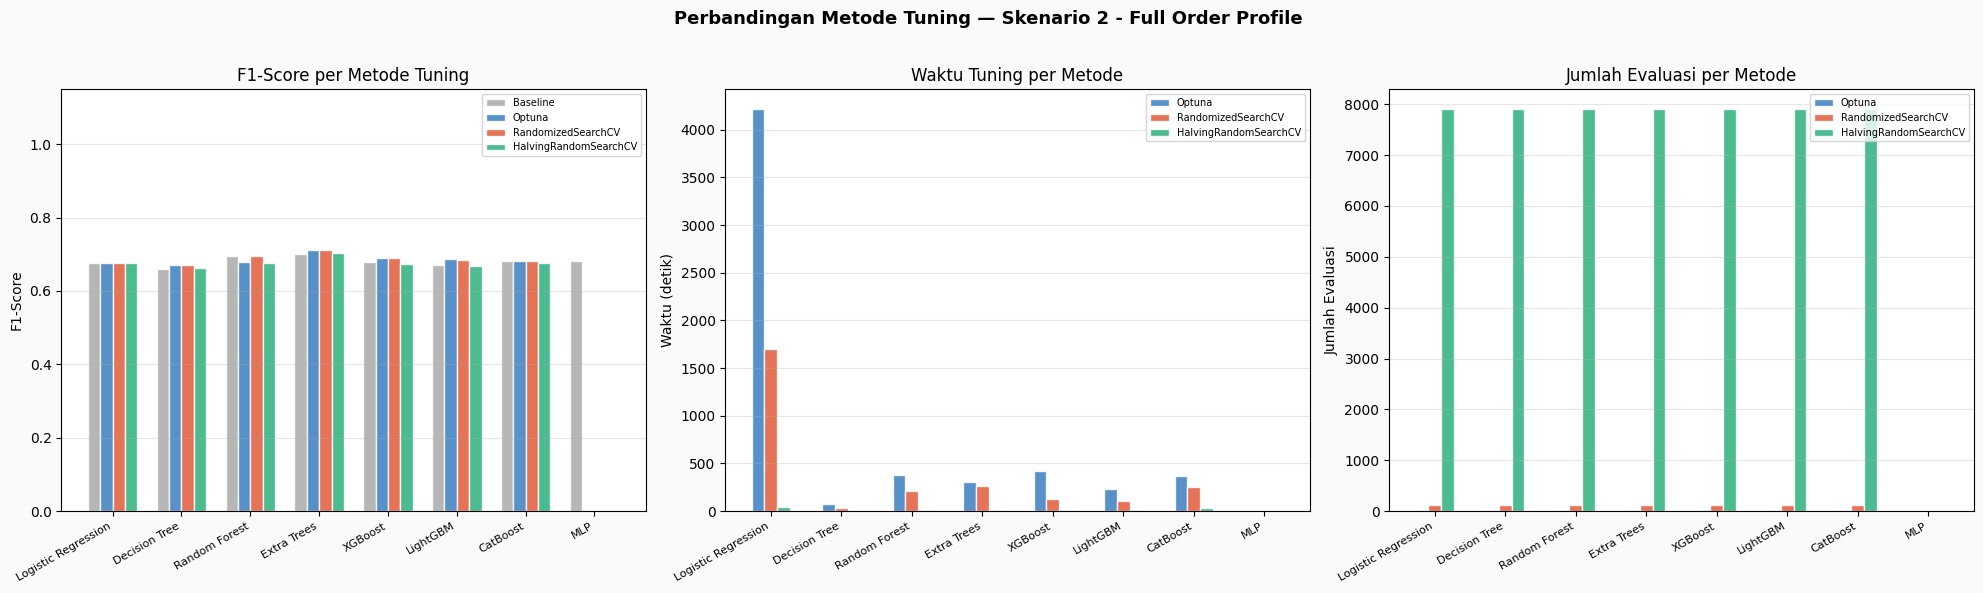

In [27]:
# Seknario 2
df_cmp_s2 = summarize_tuning_comparison(
    results_baseline_s2, results_optuna_s2,
    results_random_s2,   results_halving_s2,
    label='Skenario 2 - Full Order Profile',
)
plot_tuning_comparison(df_cmp_s2, 'Skenario 2 - Full Order Profile')


In [28]:
# Summary
print("### HYPERPARAMETER TUNING ###")
metrics_keys = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']

for label, baseline_list, tuned_list, y_test in [
    ('Skenario 1', results_baseline_s1, results_optuna_s1, y_test_s1),
    ('Skenario 2', results_baseline_s2, results_optuna_s2, y_test_s2),
]:
    best_name = sorted(tuned_list, key=lambda r: r['F1-Score'], reverse=True)[0]['Model']
    before = next(r for r in baseline_list if r['Model'] == best_name)
    after  = next(r for r in tuned_list   if r['Model'] == best_name)
    print(f"\n{label} — {best_name}:")
    print(f"  {'Metrik':<12} {'Baseline':>10} {'Optuna':>10} {'Selisih':>10}")
    print(f"  {'-'*45}")
    for m in metrics_keys:
        diff = after[m] - before[m]
        flag = '+' if diff >= 0 else ''
        print(f"  {m:<12} {before[m]:>10.4f} {after[m]:>10.4f} {flag}{diff:>9.4f}")

### HYPERPARAMETER TUNING ###

Skenario 1 — Random Forest:
  Metrik         Baseline     Optuna    Selisih
  ---------------------------------------------
  Accuracy         0.6748     0.6919 +   0.0171
  Precision        0.7650     0.7968 +   0.0318
  Recall           0.5874     0.5880 +   0.0006
  F1-Score         0.6645     0.6767 +   0.0122
  ROC-AUC          0.7181     0.7419 +   0.0238

Skenario 2 — Extra Trees:
  Metrik         Baseline     Optuna    Selisih
  ---------------------------------------------
  Accuracy         0.6796     0.6011   -0.0785
  Precision        0.7172     0.5891   -0.1281
  Recall           0.6862     0.9010 +   0.2148
  F1-Score         0.7014     0.7124 +   0.0110
  ROC-AUC          0.7469     0.7337   -0.0132


In [29]:
## Simpan model terbaik
best_final_s1 = sorted(results_optuna_s1, key=lambda r: r['F1-Score'], reverse=True)[0]
best_final_s2 = sorted(results_optuna_s2, key=lambda r: r['F1-Score'], reverse=True)[0]

save_model(best_final_s1['_model'], '../models/tuned_model_s1.pkl')
save_model(best_final_s2['_model'], '../models/tuned_model_s2.pkl')

print(f"\nModel Final Skenario 1: {best_final_s1['Model']} | F1={best_final_s1['F1-Score']}")
print(f"Model Final Skenario 2: {best_final_s2['Model']} | F1={best_final_s2['F1-Score']}")
print("\nBest Params S1:", best_final_s1['_best_params'])
print("Best Params S2:", best_final_s2['_best_params'])


Model disimpan: ../models/tuned_model_s1.pkl
Model disimpan: ../models/tuned_model_s2.pkl

Model Final Skenario 1: Random Forest | F1=0.6767
Model Final Skenario 2: Extra Trees | F1=0.7124

Best Params S1: {'n_estimators': 120, 'max_depth': 3, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
Best Params S2: {'n_estimators': 297, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}
